In [6]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [ ]:
# Preprocess
# Apply blur to reduce noise
# hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

"""
Need study more to define better range values with pre-process
"""


In [7]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value) after pre-process
lower_red1 = [0, 100, 255]
upper_red1 = [10, 255, 255]
lower_red2 = [160, 240, 0]
upper_red2 = [180, 255, 255]
"""

'\nWriting down values (Hue, Saturation, Value) after pre-process\nlower_red1 = [0, 100, 255]\nupper_red1 = [10, 255, 255]\nlower_red2 = [160, 240, 0]\nupper_red2 = [180, 255, 255]\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

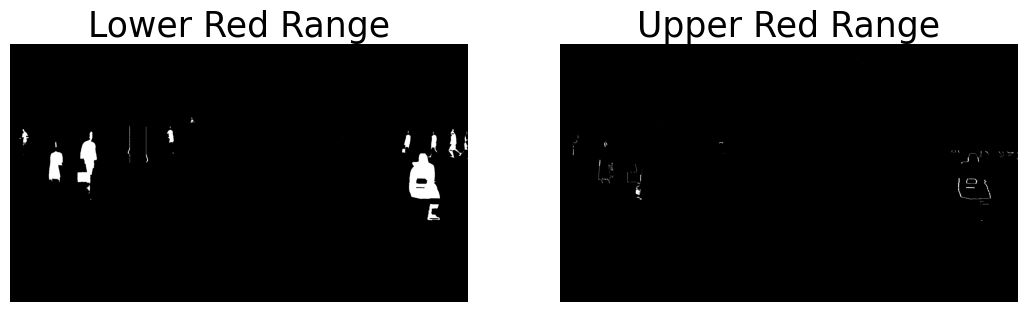

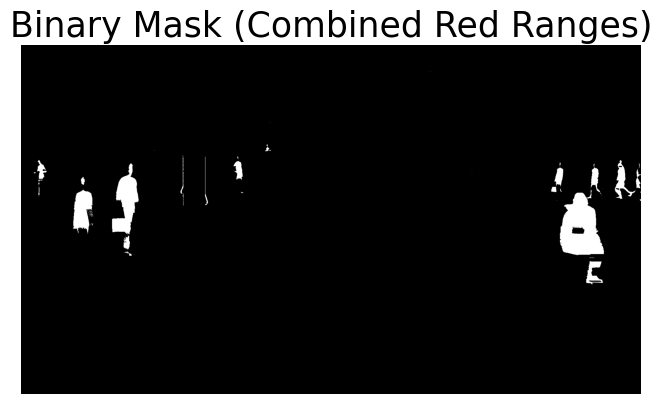

In [8]:
### Process ###
# First Step - Define two color ranges for red
# Range 1 - Lower red range (0-10) - Without pre-process - OK!
lower_red1 = np.array([0, 100, 255])
upper_red1 = np.array([10, 255, 255])

# Range 2 - Upper red range (160-180) - Without pre-process - OK!
lower_red2 = np.array([160, 240, 0])
upper_red2 = np.array([180, 255, 255])

## Range 1 - Lower red range (0-10) - With pre-process - Not good
# lower_red1 = np.array([0, 100, 255])
# upper_red1 = np.array([10, 255, 255])

## Range 2 - Upper red range (160-180) - With pre-process - Not good
# lower_red2 = np.array([160, 230, 0])
# upper_red2 = np.array([180, 255, 255])

# Second Step - Create binary masks for each range
mask1 = cv.inRange(hsv_img, lower_red1, upper_red1)
mask2 = cv.inRange(hsv_img, lower_red2, upper_red2)

# Combine both masks with OR operation
mask = cv.bitwise_or(mask1, mask2)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask1, cmap='gray')
plt.title(f"Lower Red Range",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2, cmap='gray')
plt.title("Upper Red Range",fontdict={'fontsize': 25})
plt.axis('off')

# Visualize combined binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask (Combined Red Ranges)", fontdict={'fontsize': 25})
plt.axis('off')


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

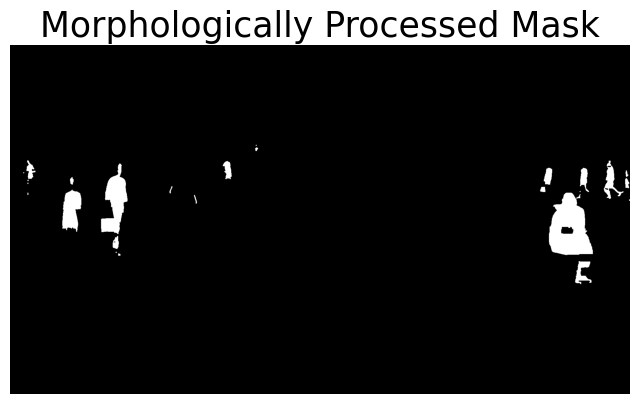

In [9]:
# Morphologic Operations
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Morphologically Processed Mask", fontdict={'fontsize': 25})
plt.axis('off')


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

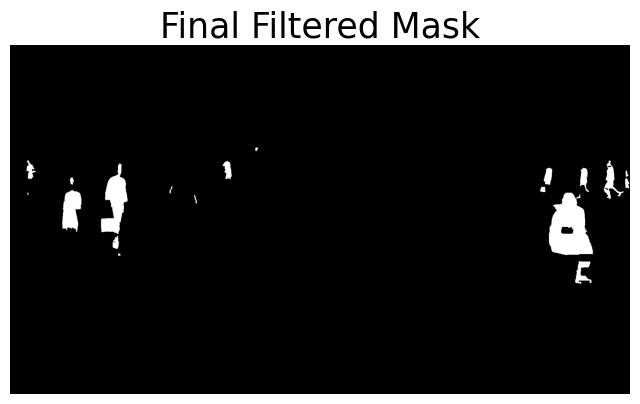

In [10]:
# Remove Noise by Filtering Small Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 10

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# Visualize final mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Final Filtered Mask", fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

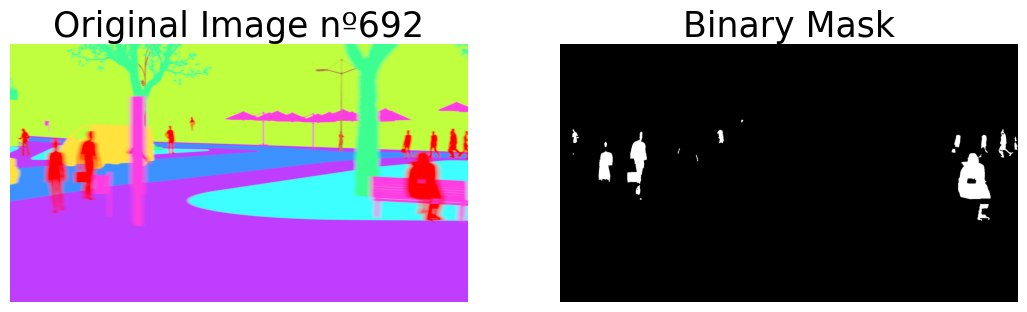

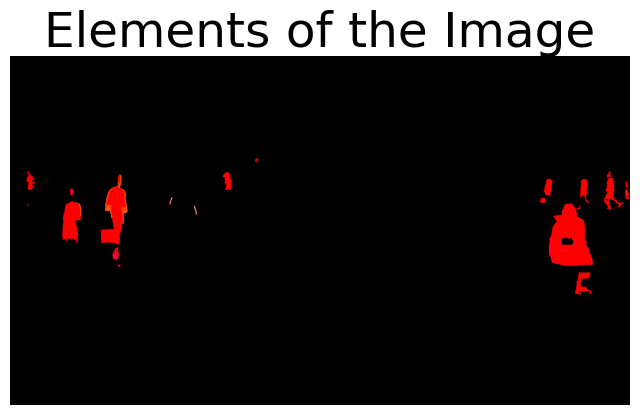

In [11]:
# Visualize Segmentation Results
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}", fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask", fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask to original image
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image", fontdict={'fontsize': 35})
plt.axis('off')


In [84]:
# 3.5 - Check Result values
cv.imshow("Inspect Result", result)
cv.waitKey(0)
cv.destroyAllWindows()